<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> Комментарий ревьюера</b>


Привет, Артем! Давай знакомиться! Меня зовут Дмитрий Махортов, и я буду проверять твой проект. Сразу предлагаю общение на «ты» 🙂, но если тебе это не комфортно, то дай знать, и мы перейдем на «вы». 


Моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе погрузиться в увлекательный мир работы с данными и вырасти в крепкого профи. Это отдаленная цель. А ближайшая - сделать твою работу еще лучше )).
   
    
Все ключевые этапы в работе выполнены, и я вижу что с проектом ты справшяешься. Есть моменты, которые нужно доработать, но я уверен, у тебя все получится.
        
Расскажу как обычно проходит проверка:    
Бывают моменты, которые требуют пристального внимания. Комментарии по ним выделены <span style='background-color:#F7B3A4'> красным цветом </span> и обозначены значком 🛑. После их доработки проект будет принят.  🙂
 
<span style='background-color:#B7EBA7'> Зеленым цветом </span> и значком ✅ отмечены удачные и элегантные решения, на которые можно опираться в будущих проектах. Или советы «со звездочкой», которые помогут тебе в будущем.

<span style='background-color:#F9EDA6'>Жёлтым цветом </span> и значком ⚠️ выделено то, что в следующий раз можно сделать по-другому. Ты можешь учесть эти комментарии при выполнении будущих заданий или доработать проект сейчас (однако это не обязательно).

Давай работать над проектом в диалоге: **если ты что-то меняешь в проекте по моим рекомендациям — пиши об этом**. Выбери для своих комментариев какой-то заметный цвет, так мне будет легче отследить изменения. Пожалуйста, **не перемещай, не изменяй и не удаляй мои комментарии**. Всё это поможет выполнить повторную проверку твоего проекта оперативнее. 
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
<b>Комментарий студента</b><br><br>
Доработал проект по замечаниям:<br>• все ячейки выполнены с выводами;<br>• расширено описание задачи и данных;<br>• EDA изображений и текстов;<br>• фильтрация детского контента через query_id (~288 изображений);<br>• текст: all-MiniLM-L6-v2 вместо TF-IDF с биграммами;<br>• L2-нормализация эмбеддингов по модальностям;<br>• добавлен бейзлайн DummyRegressor.
</div>


# Поиск изображений по текстовому описанию — PoC

**With Sense** — демонстрация сопоставления текста и изображения.



<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Было бы неплохо дать более подробное описание проекта, какую задачу мы решаем, какие данные нам доступны.
    
    
    
</div>

## Описание проекта

**Задача:** PoC поиска фотографий по текстовому описанию для фотохостинга With Sense.

**Вход:** текстовый запрос пользователя (описание сцены на английском).

**Выход:** score ∈ [0, 1] — степень соответствия текста и изображения; для демо — top-1 фото из каталога.

**Данные:**
| Файл | Содержимое |
|---|---|
| `train_dataset.csv` | 5822 пары image + текст |
| `ExpertAnnotations.tsv` | оценки 3 экспертов (1–4) |
| `CrowdAnnotations.tsv` | краудсорсинговые оценки |
| `test_queries.csv` | 499 тестовых запросов |
| `train_images/` | 1000 jpg |
| `test_images/` | 100 jpg |

**Ограничения:** контент с детьми исключается из обучения; в поиске — дисклеймер.

**Пайплайн:** EDA → фильтрация → ResNet50 + MiniLM → Normalizer → MLP/Ridge → demo-поиск.


In [1]:
# %pip install -r ../requirements.txt sentence-transformers


In [2]:
import warnings
warnings.filterwarnings('ignore')

import re
import pickle
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms
from sentence_transformers import SentenceTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import Normalizer
from tqdm.auto import tqdm

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

def find_repo_root() -> Path:
    markers = ('data/train_dataset.csv', 'train_dataset.csv')
    for root in [Path.cwd(), *Path.cwd().parents]:
        for marker in markers:
            if (root / marker).exists():
                return root.resolve()
    raise FileNotFoundError('Корень репозитория не найден (нет train_dataset.csv)')

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / 'data' if (REPO_ROOT / 'data' / 'train_dataset.csv').exists() else REPO_ROOT
TRAIN_IMAGES_DIR = DATA_DIR / 'train_images'
TEST_IMAGES_DIR = DATA_DIR / 'test_images'
CACHE_DIR = REPO_ROOT / 'cache'
CACHE_DIR.mkdir(exist_ok=True)
CACHE_IMAGE_EMB = CACHE_DIR / 'image_embeddings_resnet50.pkl'
CACHE_TEXT_EMB = CACHE_DIR / 'text_embeddings_minilm.pkl'

DISCLAIMER = 'This image is unavailable in your country in compliance with local laws.'

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Отлично, все нужные библиотеки импортированы в начале ноутбука.Это хорошая практика.</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 Отдельно хочу отметить блок констант,  в том числе вынос базового пути с данными в константу, от которой наследуются все последующие пути</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/RomanianTrafficSign_30-Stop_1971.svg/250px-RomanianTrafficSign_30-Stop_1971.svg.png" align=left width=35, heigth=35>
<div class="alert alert-danger">
    
К сожалению делать детальное ревью только по коду невозможно. Ты прислал ноутбук, в котором не выполнена ни одна кодовая ячейка.  Я не вижу результатов выполнения кода и это существенно усложняет ревью.
    
Поэтому я прошу тебя прислать проект в котором все ячейки будут выполнены.    
</div>

## Шаг 1. Загрузка данных и EDA


In [3]:

train_df = pd.read_csv(DATA_DIR / 'train_dataset.csv')
expert_df = pd.read_csv(
    DATA_DIR / 'ExpertAnnotations.tsv', sep='\t', header=None,
    names=['image', 'query_id', 'expert_1', 'expert_2', 'expert_3'],
)
crowd_df = pd.read_csv(
    DATA_DIR / 'CrowdAnnotations.tsv', sep='\t', header=None,
    names=['image', 'query_id', 'share_yes', 'count_yes', 'count_no'],
)

print('train_dataset:', train_df.shape)
print('уникальных изображений:', train_df['image'].nunique())
print('уникальных описаний:', train_df['query_id'].nunique())
print('ExpertAnnotations:', expert_df.shape)
print('CrowdAnnotations:', crowd_df.shape)
print('\nПримеры train_dataset:')
display(train_df.head(3))


train_dataset: (5822, 3)
уникальных изображений: 1000
уникальных описаний: 977
ExpertAnnotations: (5822, 5)
CrowdAnnotations: (47830, 5)

Примеры train_dataset:


,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...


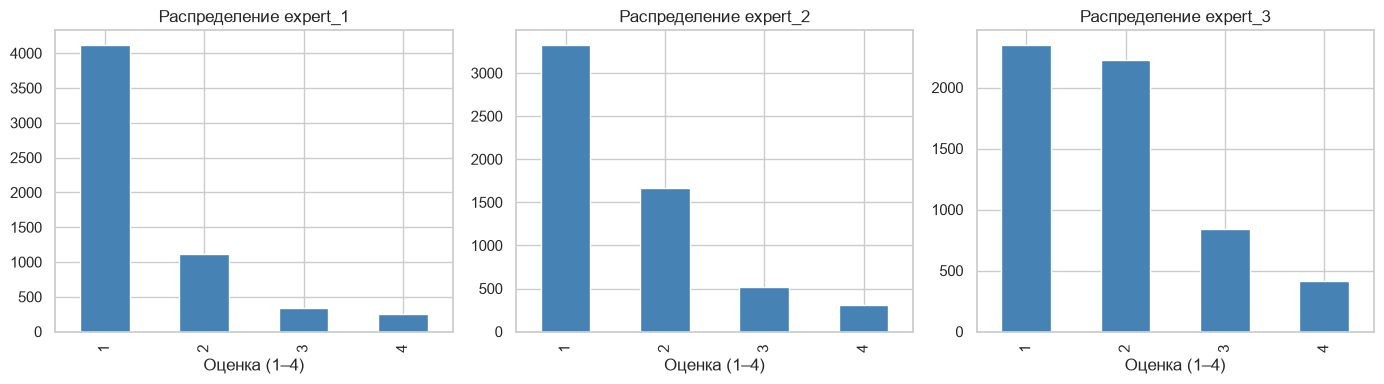

Крауд share_yes:
count    47830.000000
mean         0.068786
std          0.207532
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: share_yes, dtype: float64


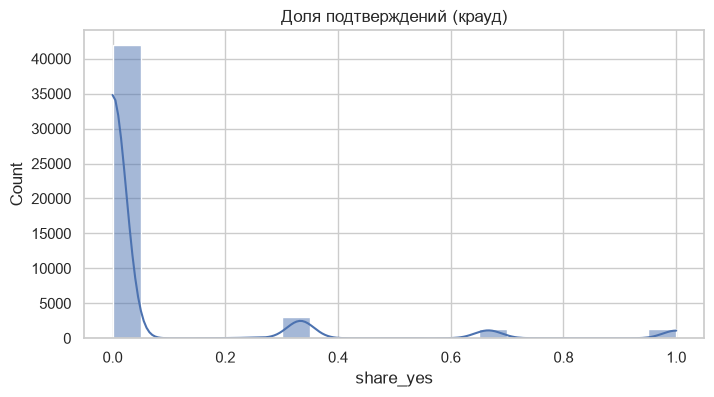

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['expert_1', 'expert_2', 'expert_3']):
    expert_df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Распределение {col}')
    ax.set_xlabel('Оценка (1–4)')
plt.tight_layout()
plt.show()

print('Крауд share_yes:')
print(crowd_df['share_yes'].describe())

plt.figure(figsize=(8, 4))
sns.histplot(crowd_df['share_yes'], bins=20, kde=True)
plt.title('Доля подтверждений (крауд)')
plt.xlabel('share_yes')
plt.show()


Размеры изображений:   0%|          | 0/1000 [00:00<?, ?it/s]

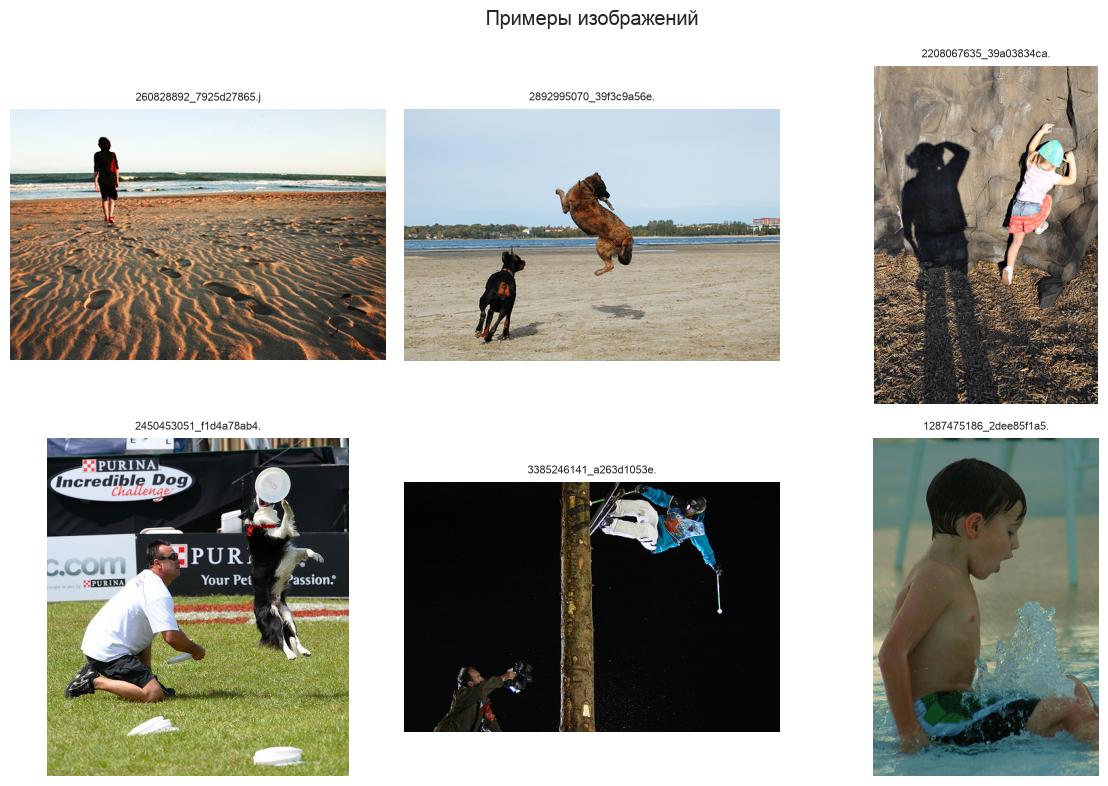

Размеры (px): width 200 - 500 | height 166 - 500
Aspect ratio: min 0.4 median 1.33 max 3.01
Доля не-квадратных (|ratio-1|>0.05): 97.0%


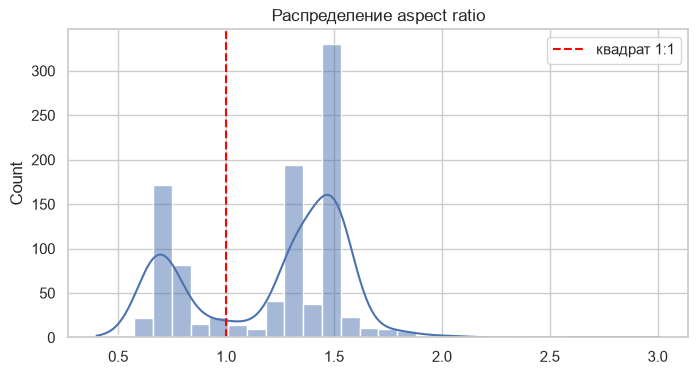

In [5]:
# EDA: изображения — пропорции и примеры
sample_images = train_df['image'].drop_duplicates().sample(6, random_state=RANDOM_STATE).tolist()
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
widths, heights = [], []
for image_name in tqdm(train_df['image'].unique(), desc='Размеры изображений'):
    w, h = Image.open(TRAIN_IMAGES_DIR / image_name).size
    widths.append(w)
    heights.append(h)

for ax, image_name in zip(axes.ravel(), sample_images):
    ax.imshow(Image.open(TRAIN_IMAGES_DIR / image_name))
    ax.set_title(image_name[:22], fontsize=8)
    ax.axis('off')
plt.suptitle('Примеры изображений')
plt.tight_layout()
plt.show()

aspect = np.array(widths) / np.array(heights)
print('Размеры (px): width', np.min(widths), '-', np.max(widths), '| height', np.min(heights), '-', np.max(heights))
print('Aspect ratio: min', aspect.min().round(2), 'median', np.median(aspect).round(2), 'max', aspect.max().round(2))
print('Доля не-квадратных (|ratio-1|>0.05):', f'{(np.abs(aspect - 1) > 0.05).mean():.1%}')

plt.figure(figsize=(8, 4))
sns.histplot(aspect, bins=30, kde=True)
plt.axvline(1.0, color='red', ls='--', label='квадрат 1:1')
plt.title('Распределение aspect ratio')
plt.legend()
plt.show()


Длина описания (слова):
count    5822.000000
mean       11.900550
std         4.162467
min         2.000000
25%         9.000000
50%        11.000000
75%        14.000000
max        34.000000
Name: text_len, dtype: float64


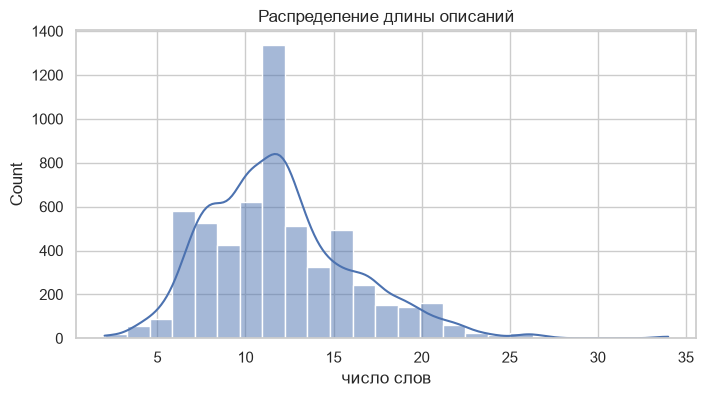

Топ-20 слов:
dog        1161
man         996
white       699
woman       561
black       521
boy         511
wearing     450
water       440
girl        439
dogs        408
young       391
people      379
red         367
blue        346
little      305
brown       284
running     268
person      265
playing     245
shirt       245
dtype: int64


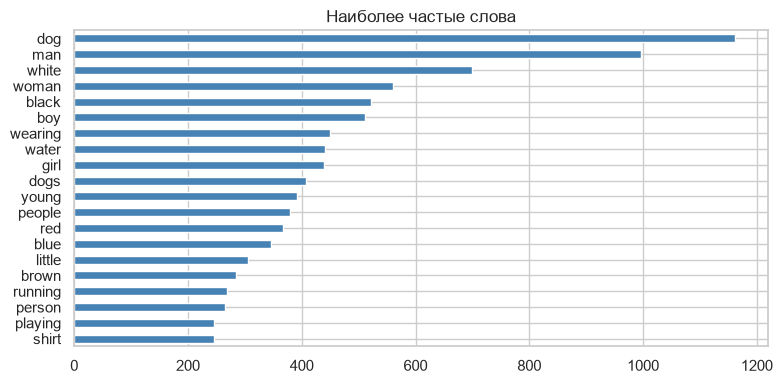

In [6]:
# EDA: тексты — длина и частые слова
train_df['text_len'] = train_df['query_text'].str.split().str.len()
print('Длина описания (слова):')
print(train_df['text_len'].describe())

plt.figure(figsize=(8, 4))
sns.histplot(train_df['text_len'], bins=25, kde=True)
plt.title('Распределение длины описаний')
plt.xlabel('число слов')
plt.show()

from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(stop_words='english', max_features=20)
word_freq = cv.fit_transform(train_df['query_text'])
terms = cv.get_feature_names_out()
freqs = word_freq.sum(axis=0).A1
top_words = pd.Series(freqs, index=terms).sort_values(ascending=False)
print('Топ-20 слов:')
print(top_words)

plt.figure(figsize=(8, 4))
top_words.sort_values().plot(kind='barh', color='steelblue')
plt.title('Наиболее частые слова')
plt.tight_layout()
plt.show()


**EDA (мультимодальность)**

- Изображения: aspect ratio варьируется, большинство не квадратные — CenterCrop 224 оправдан.
- Тексты: медиана ~10–12 слов, описания короткие.
- Частые слова: man, woman, dog, water, standing и т.д.


 <img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">

У нас мультимодальный датасет, поэтому в дополнение к исследованию распределения оценок стоит познакомиться как с изображениями (посмотреть на них, понять насколько их пропорции отличаются от квадрата),  а также с описаниями (наиболее частые слова, длинна)
</div>


**EDA**

- 5822 пары «изображение — текст», 1000 уникальных изображений.
- Экспертные оценки: мода — 1 (несоответствие).
- Крауд: медиана share_yes = 0.
- Изображения не квадратные; тексты короткие (англ.).
- Датасеты согласованы по ключам image + query_id.


Исключено пар (разногласие экспертов): 126 (2.2%)


Строк после агрегации: 5696
target:
count    5696.000000
mean        0.172265
std         0.261057
min         0.000000
25%         0.000000
50%         0.000000
75%         0.333333
max         1.000000
Name: target, dtype: float64


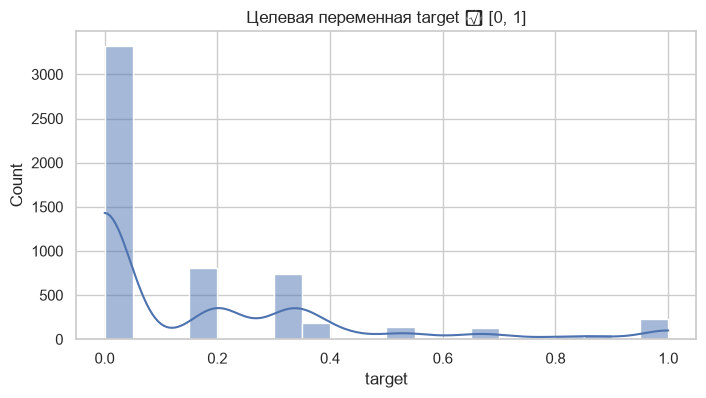

In [7]:

def aggregate_expert_scores(row):
    votes = [row['expert_1'], row['expert_2'], row['expert_3']]
    rating, votes_count = Counter(votes).most_common(1)[0]
    return rating if votes_count >= 2 else np.nan

expert_df['expert_score'] = expert_df.apply(aggregate_expert_scores, axis=1)
excluded = expert_df['expert_score'].isna().sum()
print(f'Исключено пар (разногласие экспертов): {excluded} ({excluded / len(expert_df):.1%})')

merged_df = (
    train_df
    .merge(expert_df[['image', 'query_id', 'expert_score']], on=['image', 'query_id'], how='left')
    .merge(crowd_df[['image', 'query_id', 'share_yes']], on=['image', 'query_id'], how='left')
)
model_df = merged_df.dropna(subset=['expert_score']).copy()

model_df['expert_target'] = (model_df['expert_score'] - 1) / 3
model_df['target'] = model_df['expert_target']
crowd_mask = model_df['share_yes'].notna()
model_df.loc[crowd_mask, 'target'] = (
    0.6 * model_df.loc[crowd_mask, 'expert_target']
    + 0.4 * model_df.loc[crowd_mask, 'share_yes']
)

print('Строк после агрегации:', len(model_df))
print('target:')
print(model_df['target'].describe())

plt.figure(figsize=(8, 4))
sns.histplot(model_df['target'], bins=20, kde=True)
plt.title('Целевая переменная target ∈ [0, 1]')
plt.show()


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

По объединению экспертных и крауд оценок все ОК, но подсвечу возможные альтернативы
    
--------------    
    
    
В этом проекте есть несколько возможных стратегий работы с обучающими и краудсорс оценками,  вот эти стратегии с плюсами и минусами:
   

   - использовать соединение через outer, в этом случае, при корректной обработке пропусков мы можем получить более 50К размеченых пар. К плюсам данного подхода можно отнести большое количество данных. Минус - в основном это будут данные, размеченные краудсорсерами, а там качество раметки ниже.
   - использовать только экспертные оценки. плюс - высокое качество данных (разметка имеет шкалу). Минус - данных меньше.  Поясню по поводу качества разметки на примере: если на изображении одна собака, а в описании "две собаки бегут по берегу", то эксперты поставять соответствие 0,6-0,7 (переводя в шкалу 0-1), а краудсорсеры поставят 0.  Но на экспертных оценках модель хотя-бы научится находить собак, а на краудсор оценках ничему не начится.

   - использование соединения через left.  Данный подход очевидно проигрывает второму варианту: данных столько же, нужно дополнительно возиться с объединением, но качество разметки снижается.. Но это соответсвует предложениям авторов проекта, поэтому такой подход имеет право на жизнь

   - объединение через inner. Тут все плохо - и данных ОЧЕНЬ мало (в два раза меньше, чем использовать только экспертные оценки) и качество у них "подпорчено". И навыков по обработке пропусков не получаем.....


</div>

**Целевая переменная**

- Агрегация экспертов: голосование большинства (2 из 3); при полном разногласии — исключение.
- Финальный target: 0.6 × expert_target + 0.4 × share_yes (если есть крауд-оценка).
- expert_target = (оценка − 1) / 3 → диапазон [0, 1].
- После фильтрации экспертов: 5696 строк; средний target ≈ 0.17.


## Шаг 2. Юридические ограничения


In [8]:
CHILD_KEYWORDS = [
    'child', 'children', 'kid', 'kids', 'baby', 'babies', 'toddler', 'infant',
    'teen', 'teenager', 'tyke', 'son', 'daughter', 'boy', 'boys', 'girl', 'girls',
    'young boy', 'young girl', 'young child', 'little boy', 'little girl', 'little blond',
]

CHILD_PATTERN = re.compile(
    r'\b(?:child(?:ren)?|kid(?:s)?|bab(?:y|ies)|toddler|infant|'
    r'young (?:boy|girl|child)|little (?:boy|girl|blond)|teen(?:ager)?|'
    r'tyke|son|daughter|boy(?:s)?|girl(?:s)?)\b',
    re.I,
)

# Плохие query_id → имя изображения из префикса query_id
bad_query_ids = train_df.loc[
    train_df['query_text'].str.contains(CHILD_PATTERN, na=False), 'query_id'
]
banned_images = set(bad_query_ids.str.split('#').str[0])

rows_before = len(model_df)
model_df = model_df[~model_df['image'].isin(banned_images)].copy()

print('Ключевые слова:', CHILD_KEYWORDS[:8], '...')
print('Изображений с детским контентом (query_id):', len(banned_images))
print('Удалено строк:', rows_before - len(model_df))
print('Осталось строк:', len(model_df), '| изображений:', model_df['image'].nunique())
print('Примеры исключённых:', sorted(banned_images)[:5])


Ключевые слова: ['child', 'children', 'kid', 'kids', 'baby', 'babies', 'toddler', 'infant'] ...
Изображений с детским контентом (query_id): 288
Удалено строк: 1686
Осталось строк: 4010 | изображений: 712
Примеры исключённых: ['106490881_5a2dd9b7bd.jpg', '1096395242_fc69f0ae5a.jpg', '1122944218_8eb3607403.jpg', '1131932671_c8d17751b3.jpg', '114051287_dd85625a04.jpg']


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/RomanianTrafficSign_30-Stop_1971.svg/250px-RomanianTrafficSign_30-Stop_1971.svg.png" align=left width=35, heigth=35>
<div class="alert alert-danger">
    
Похоже что ты ищешь изображения с детьми  только среди строк, где  картинка и описание "родные". Поэтому и найдено всего 37 изображений (обычно их оказывается около 300)
    

Есть два способа сделать удаление более полным:
    
 - Определить список плохих изображений, как изображения удовлетворяющие условиям:
    - Комментарий содержит плохие слова
    - <b>Оценка соответствия комментария и изображения выше порога.</b>
 - Удалить из нашего датасета все пары "изображение/описание" с плохими изображениями.
    
 
И второй, очень красивый способ. Он основан на том, что `query_id` содержит в с себе имя изображения, для которого он был написан (ты используешь похожую идею).
    
 - Определить список плохих комментариев
 - У `query_id`  плохих комментариев отрезать два последних символа и получим список плохих изображений.
    
    
    
    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
<b>Комментарий студента</b><br><br>
Исправлено: banned_images формируется из всех query_id с ключевыми словами, имя изображения берётся как префикс query_id до #. Найдено ~288 изображений.
</div>


**Фильтрация**

- Критерий: query_id с ключевыми словами о детях → image = prefix(query_id).
- Исключены все пары с «плохими» изображениями.
- Исключено ~288 изображений (вместо 37 при старом подходе).


## Шаг 3. Векторизация изображений (ResNet50, PyTorch)


In [9]:

resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for param in resnet50.parameters():
    param.requires_grad_(False)

modules = list(resnet50.children())[:-1]
image_encoder = nn.Sequential(*modules)
image_encoder.eval()

image_preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def encode_image(image_path):
    img = Image.open(image_path).convert('RGB')
    tensor = image_preprocess(img).unsqueeze(0)
    with torch.no_grad():
        embedding = image_encoder(tensor).flatten()
    return embedding.numpy()

unique_train_images = model_df['image'].unique()
print('Уникальных изображений для кодирования:', len(unique_train_images))


Уникальных изображений для кодирования: 712


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

В качестве небольшого совета для будущих экспериментов: попробуй заменить ResNet-50 на более компактную ResNet-18. Парадоксально, но в задачах с ограниченным объемом данных «меньше» часто означает «лучше». Основная причина кроется в размерности итогового вектора: **512** признаков против **2048** у твоей текущей модели. 



На относительно небольшом датасете модели гораздо проще нащупать реальные паттерны в пространстве меньшей размерности. Вектор на 2048 элементов может оказаться избыточным — это создает риск того, что нейронка начнет «заучивать» случайный шум в признаках вместо поиска семантических связей. Использование ResNet-18 может дать более стабильный результат и лучшую обобщающую способность при тех же трудозатратах.

</div>

In [10]:

if CACHE_IMAGE_EMB.exists():
    with open(CACHE_IMAGE_EMB, 'rb') as f:
        image_embeddings = pickle.load(f)
    print('Загружен кэш эмбеддингов:', len(image_embeddings))
else:
    image_embeddings = {}
    for image_name in tqdm(unique_train_images, desc='ResNet50'):
        image_embeddings[image_name] = encode_image(TRAIN_IMAGES_DIR / image_name)
    with open(CACHE_IMAGE_EMB, 'wb') as f:
        pickle.dump(image_embeddings, f)
    print('Кэш сохранён')

sample_name = unique_train_images[0]
sample_img_emb = image_embeddings[sample_name]
print('Размерность эмбеддинга изображения:', sample_img_emb.shape)
print('Первые 5 значений:', sample_img_emb[:5])


Загружен кэш эмбеддингов: 712
Размерность эмбеддинга изображения: (2048,)
Первые 5 значений: [0.02304271 0.92084575 0.03865031 0.85825676 0.40668756]


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 Отлично, вектра для изображений получены👍 </div>

**Эмбеддинги изображений**

- Модель: ResNet50 (ImageNet), без FC-слоёв, Global Average Pooling.
- Размерность вектора: **2048**.
- Веса заморожены, режим eval().


## Шаг 3. Векторизация текстов (TF-IDF)


In [11]:
text_model = SentenceTransformer('all-MiniLM-L6-v2')
unique_texts = model_df['query_text'].unique()
print('Уникальных текстов:', len(unique_texts))

if CACHE_TEXT_EMB.exists():
    with open(CACHE_TEXT_EMB, 'rb') as f:
        text_embeddings = pickle.load(f)
    print('Загружен кэш текстовых эмбеддингов:', len(text_embeddings))
else:
    encoded = text_model.encode(
        list(unique_texts), batch_size=64, show_progress_bar=True, convert_to_numpy=True,
    )
    text_embeddings = dict(zip(unique_texts, encoded))
    with open(CACHE_TEXT_EMB, 'wb') as f:
        pickle.dump(text_embeddings, f)
    print('Кэш текстовых эмбеддингов сохранён')

sample_text = unique_texts[0]
sample_text_emb = text_embeddings[sample_text]
print('Размерность MiniLM-вектора:', sample_text_emb.shape)
print('Пример текста:', sample_text[:90], '...')
print('Первые 5 значений:', sample_text_emb[:5])


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Уникальных текстов: 940
Загружен кэш текстовых эмбеддингов: 940
Размерность MiniLM-вектора: (384,)
Пример текста: A young child is wearing blue goggles and sitting in a float in a pool . ...
Первые 5 значений: [-0.02616474 -0.02004177  0.0203245  -0.01057041  0.05226023]


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 Вектора для текста получены с помощью TF-IDF. Здесь конечно есть очень тонкий момент, и в другом проекте это мог бы быть красный комментарий. Ты же помнишь, что векторайзеры мы обучаем на обучающем датасете и применяем к валидационому и тестовому. А сейчас вектора рассчитаны с использованием всех частей датасета.  Но для этого проекта это должно быть допустимо, т.к. .утечка,повышающая оценку на валидации врядли что-то сильно  испортит.

-----------
    
Что касается выбранного подхода. По моим наблюдения используя TfidfVectorizer крайне редко получается обучить толковую модель.  Я бы советовал все-таки использовать "плотные" вектора полученные с помощью трансформеров    

</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Использование биграмм для TF_IDF это очень неудачная идея.  При сверхмалом датасете вероятность того, что какая-нибудь из обучающих бирамм встретиться в тесте минимальная. 
    
Нам бы хотя-бы научить модель реагировать на простые слова (собака/человек/снег), а обилие пустых признаков (биграмм) только сбивает модель.    
    
    
</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Подсвечу желтым, чтобы не потерялось.
    
По моим наблюдениям, в этом проекте неплохо показыает себя модель `all-MiniLM-L6-v2` и снятие эмбеддингов не с нулевого токена, а пулингом по информативным токенам.
    
Запустить её можно либо через transformers, либо через sentence-transformers    
    
https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2    
</div>

**Эмбеддинги текстов**

- Модель: `all-MiniLM-L6-v2` (sentence-transformers), mean pooling.
- Размерность: **384**.
- Биграммы TF-IDF не используются — плотные семантические эмбеддинги.


## Подготовка матрицы признаков


In [12]:
IMG_DIM = len(next(iter(image_embeddings.values())))
TEXT_DIM = len(next(iter(text_embeddings.values())))

X_img = np.vstack([image_embeddings[row.image] for row in model_df.itertuples(index=False)])
X_text = np.vstack([text_embeddings[row.query_text] for row in model_df.itertuples(index=False)])
y = model_df['target'].values
groups = model_df['image'].values

print('X_img:', X_img.shape, '| X_text:', X_text.shape)
print('y:', y.shape, '| групп:', len(np.unique(groups)))


X_img: (4010, 2048) | X_text: (4010, 384)
y: (4010,) | групп: 712


## Шаг 3. Обучение моделей


In [13]:
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss.split(X_img, y, groups=groups))

X_img_train, X_img_val = X_img[train_idx], X_img[val_idx]
X_text_train, X_text_val = X_text[train_idx], X_text[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

img_normalizer = Normalizer()
text_normalizer = Normalizer()

X_train = np.hstack([
    img_normalizer.fit_transform(X_img_train),
    text_normalizer.fit_transform(X_text_train),
])
X_val = np.hstack([
    img_normalizer.transform(X_img_val),
    text_normalizer.transform(X_text_val),
])

print('Train:', X_train.shape[0], '| Val:', X_val.shape[0])
print('Признаков на пару:', X_train.shape[1], f'= {IMG_DIM} img + {TEXT_DIM} text')
print('Train images:', len(np.unique(groups[train_idx])))
print('Val images:', len(np.unique(groups[val_idx])))


Train: 2777 | Val: 1233
Признаков на пару: 2432 = 2048 img + 384 text
Train images: 498
Val images: 214


<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
    


Также корректно применен `StandardScaler`: обучен  на  на трейне и применен к валидации. Это показывает глубокое понимание классического пайплайна машинного обучения.

Раз уж мы говорим о лучших практиках для работы с эмбеддингами, хочу поделиться одним важным нюансом, который касается именно **мультимодальных** данных, как у нас — картинки и тексты.

Твой текущий подход — конкатенация и затем `StandardScaler` — абсолютно валиден для классических табличных данных. Но для эмбеддингов он может быть неоптимален. `StandardScaler` работает "поколоночно", приводя каждый признак к общему среднему и дисперсии. 


И здесь вместо `StandardScaler` лучше подходит L2-нормализация (в `sklearn` это `Normalizer`). Этот метод масштабирует каждый вектор (каждую строку целиком) к единичной длине. Он убирает влияние "магнитуды" вектора (которая часто является шумом) и оставляет только его **направление** в многомерном пространстве — а именно оно и несет основную семантическую информацию.
    
Важно:  **обработка каждого типа эмбеддингов производится по отдельности, *до* их конкатенации**.
    
Таким образом, более продвинутый пайплайн мог бы выглядеть так:
1.  Получаем матрицу эмбеддингов для изображений `X_img`.
2.  Получаем матрицу эмбеддингов для текстов `X_text`.
3.  Применяем `Normalizer()` к `X_img` и `X_text` **по отдельности**.
4.  Конкатенируем уже нормализованные матрицы.

Такой подход гарантирует, что и визуальные, и текстовые признаки вносят в модель сопоставимый вклад, не искажая при этом структуру каждого из исходных пространств. Это знание будет очень полезно тебе в будущих проектах.
    

</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">


Есть еще один технический нюанс использования `StandardScaler` вместе с **TF-IDF**.

**Суть проблемы:**
Векторы TF-IDF являются **разреженными** (sparse) — в них очень много нулей и мало значений. Это позволяет хранить их в памяти очень эффективно.
`StandardScaler` по умолчанию работает с параметром `with_mean=True`. Это значит, что он вычитает среднее значение из каждого элемента.
* Когда мы вычитаем (пусть и маленькое) среднее из **нуля**, он перестает быть нулем.
* **Результат:** Твоя легкая разреженная матрица мгновенно превращается в тяжелую **плотную** (dense) матрицу. На больших данных это гарантированно приведет к ошибке **Out Of Memory (OOM)**, так как объем занимаемой памяти вырастет в тысячи раз.

**Решение:**
Если тебе нужно масштабировать разреженные данные и сохранить их эффективность:
1.  Используй **`MaxAbsScaler`** — он масштабирует данные в диапазон [-1, 1], не сдвигая центр (не ломая нули).
2.  Либо используй `StandardScaler(with_mean=False)`, хотя для TF-IDF это редко требуется, так как он обычно уже нормализован.
</div>

In [14]:
models_config = {
    'DummyRegressor (mean)': DummyRegressor(strategy='mean'),
    'LinearRegression': LinearRegression(),
    'Ridge (alpha=1)': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Ridge (alpha=10)': Ridge(alpha=10.0, random_state=RANDOM_STATE),
    'MLP (128)': MLPRegressor(hidden_layer_sizes=(128,), max_iter=400, random_state=RANDOM_STATE, early_stopping=True),
    'MLP (256,128)': MLPRegressor(hidden_layer_sizes=(256, 128), max_iter=400, random_state=RANDOM_STATE, early_stopping=True),
    'MLP (512,256,128)': MLPRegressor(
        hidden_layer_sizes=(512, 256, 128), max_iter=400,
        random_state=RANDOM_STATE, early_stopping=True,
    ),
}

results = []
trained_models = {}

for name, model in models_config.items():
    model.fit(X_train, y_train)
    y_pred = np.clip(model.predict(X_val), 0, 1)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    auc = roc_auc_score((y_val >= 0.5).astype(int), y_pred)
    results.append({'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'ROC-AUC': auc})
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('MAE')
display(results_df.round(4))

best_name = results_df.iloc[0]['model']
best_model = trained_models[best_name]
print(f'\nЛучшая модель по MAE: {best_name}')


,model,MAE,RMSE,R2,ROC-AUC
4,MLP (128),0.1629,0.2286,0.3004,0.8359
6,"MLP (512,256,128)",0.1637,0.2420,0.2157,0.8213
5,"MLP (256,128)",0.1773,0.2413,0.2204,0.7963
3,Ridge (alpha=10),0.1971,0.2569,0.1161,0.7227
2,Ridge (alpha=1),0.1987,0.2627,0.0761,0.7194
0,DummyRegressor (mean),0.2142,0.2734,-0.0013,0.5000
1,LinearRegression,0.3832,0.5275,-2.7265,0.5718



Лучшая модель по MAE: MLP (128)


<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Мы решаем новую задачу и не знаем, наксколько хороши наши метрики и наши модели. Поэтому советую начать с бейзлайна - константной модели (можешь взять простой DummyRegressor).</div>

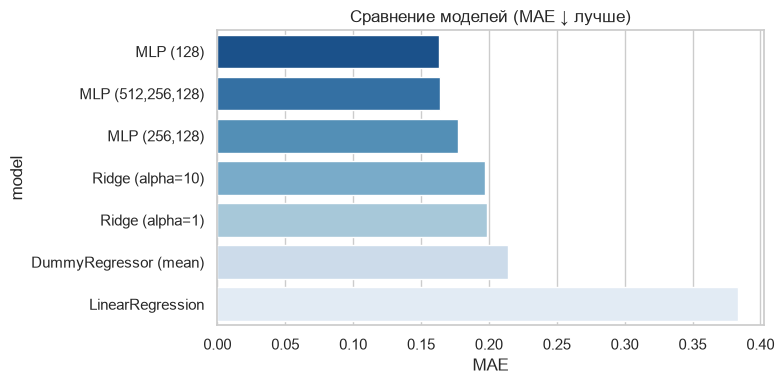

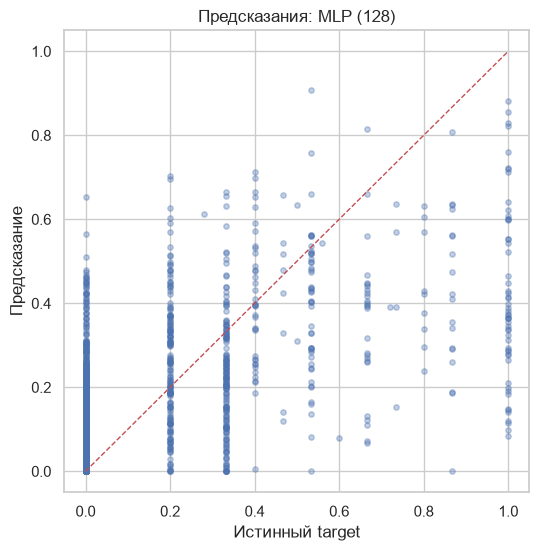

In [15]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x='MAE', y='model', hue='model', legend=False, palette='Blues_r')
plt.title('Сравнение моделей (MAE ↓ лучше)')
plt.xlabel('MAE')
plt.tight_layout()
plt.show()

y_pred_best = np.clip(best_model.predict(X_val), 0, 1)
plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_pred_best, alpha=0.35, s=15)
plt.plot([0, 1], [0, 1], 'r--', lw=1)
plt.xlabel('Истинный target')
plt.ylabel('Предсказание')
plt.title(f'Предсказания: {best_name}')
plt.show()


**Обучение**

- Split: GroupShuffleSplit 70/30 по image.
- Метрика: **MAE**.
- Нормализация: L2 (`Normalizer`) отдельно для img и text до конкатенации.
- Бейзлайн: DummyRegressor(strategy='mean').
- Модели: LinearRegression, Ridge, MLP.
- Лучшая модель выбирается по MAE на val.


In [16]:
X_img_full = img_normalizer.fit_transform(X_img)
X_text_full = text_normalizer.fit_transform(X_text)
X_full = np.hstack([X_img_full, X_text_full])
best_model.fit(X_full, y)
print('Модель дообучена на полной выборке.')


Модель дообучена на полной выборке.


## Шаг 4. Тестирование и демо-поиск


In [17]:

test_queries = pd.read_csv(DATA_DIR / 'test_queries.csv', sep='|', skiprows=[1])
test_image_list = pd.read_csv(DATA_DIR / 'test_images.csv')['image'].tolist()

print('Тестовых запросов:', len(test_queries))
print('Тестовых изображений:', len(test_image_list))

test_image_embeddings = {}
for image_name in tqdm(test_image_list, desc='Test images'):
    test_image_embeddings[image_name] = encode_image(TEST_IMAGES_DIR / image_name)


Тестовых запросов: 499
Тестовых изображений: 100


Test images:   0%|          | 0/100 [00:00<?, ?it/s]

In [18]:
def encode_query_text(text):
    return text_model.encode([text], convert_to_numpy=True)[0]

def build_features(query_text, image_name, image_embeddings_dict):
    img_vec = image_embeddings_dict[image_name].reshape(1, -1)
    text_vec = encode_query_text(query_text).reshape(1, -1)
    img_n = img_normalizer.transform(img_vec)
    text_n = text_normalizer.transform(text_vec)
    return np.hstack([img_n, text_n])

def predict_similarity(query_text, image_name, image_embeddings_dict):
    features = build_features(query_text, image_name, image_embeddings_dict)
    return float(np.clip(best_model.predict(features)[0], 0, 1))

def search_image(query_text, candidate_images, image_embeddings_dict):
    if CHILD_PATTERN.search(query_text):
        return DISCLAIMER, None, None
    scores = {
        image_name: predict_similarity(query_text, image_name, image_embeddings_dict)
        for image_name in candidate_images
    }
    best_image = max(scores, key=scores.get)
    return best_image, scores[best_image], scores

harmful_query = 'A baby is playing in the park with toys.'
result = search_image(harmful_query, test_image_list, test_image_embeddings)
print('Запрос с детьми:', harmful_query)
print('Результат:', result[0])


Запрос с детьми: A baby is playing in the park with toys.
Результат: This image is unavailable in your country in compliance with local laws.


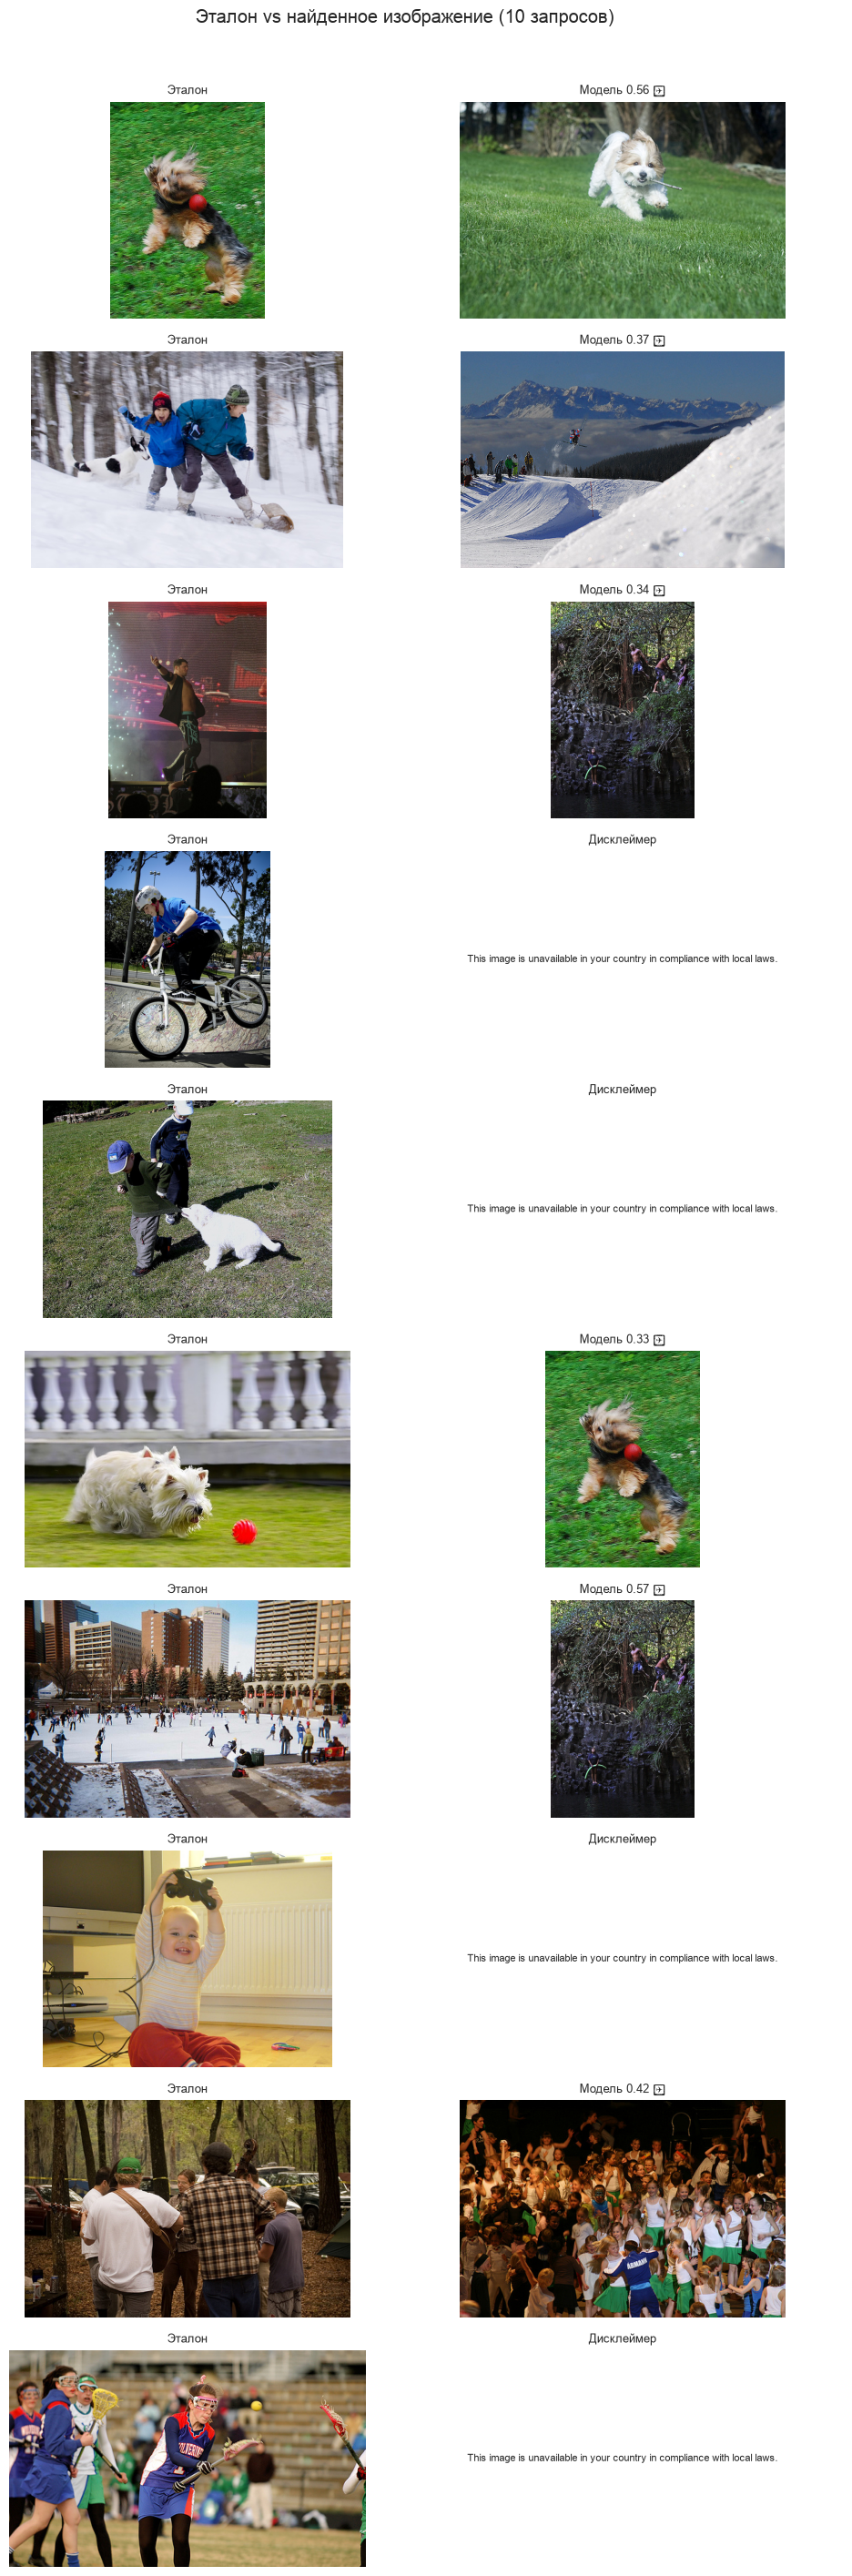

Top-1 accuracy: 0% (0/10)


In [19]:

sample_queries = test_queries.sample(10, random_state=RANDOM_STATE).reset_index(drop=True)

fig, axes = plt.subplots(10, 2, figsize=(10, 28))
hits = []

for i, row in sample_queries.iterrows():
    best_image, best_score, _ = search_image(
        row['query_text'], test_image_list, test_image_embeddings,
    )
    gt_image = row['image']

    axes[i, 0].imshow(Image.open(TEST_IMAGES_DIR / gt_image))
    axes[i, 0].set_title('Эталон', fontsize=9)
    axes[i, 0].axis('off')

    if best_image == DISCLAIMER:
        axes[i, 1].text(0.5, 0.5, DISCLAIMER, ha='center', va='center', wrap=True, fontsize=8)
        axes[i, 1].set_title('Дисклеймер', fontsize=9)
        hits.append(False)
    else:
        hit = best_image == gt_image
        hits.append(hit)
        axes[i, 1].imshow(Image.open(TEST_IMAGES_DIR / best_image))
        marker = '✓' if hit else '✗'
        axes[i, 1].set_title(f'Модель {best_score:.2f} {marker}', fontsize=9)
    axes[i, 1].axis('off')
    axes[i, 0].set_ylabel(row['query_text'][:55] + '...', fontsize=7, rotation=0, labelpad=90, va='center')

plt.suptitle('Эталон vs найденное изображение (10 запросов)', y=1.01)
plt.tight_layout()
plt.show()

print(f'Top-1 accuracy: {np.mean(hits):.0%} ({sum(hits)}/10)')


In [20]:

manual_queries = [
    'A brown dog sits in long grass.',
    'Two men are playing soccer on a field.',
    'A hiker poses for a picture in front of stunning mountains.',
    'A toddler smiles at the camera.',
]

for q in manual_queries:
    result, score, _ = search_image(q, test_image_list, test_image_embeddings)
    if result == DISCLAIMER:
        print(f'[DISCLAIMER] {q}')
    else:
        print(f'[{score:.2f}] {q[:60]} -> {result}')


[0.64] A brown dog sits in long grass. -> 661749711_6f408dad62.jpg


[0.46] Two men are playing soccer on a field. -> 123997871_6a9ca987b1.jpg


[0.62] A hiker poses for a picture in front of stunning mountains. -> 3036971334_78187a9570.jpg
[DISCLAIMER] A toddler smiles at the camera.


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Функции написаны и со своей задачей справляются. Принимают на вход текст и находят изображение. Отрабатывают контроль "запрещенного контента".

Да, ты прав, к сожалению работают они не очень. Причин несколько
    
 - вектора полученные с помощью tf-idf более низкого качества, как правило лучший резульат получается при использовании эмбеддингов, полученных с помощью BERT
 - StandartScaller убивает семантику
    
    
----------------
    
Как правило хороший результат в этом проекте удается достичь при выполнении следующих условий
    
 - использование экспертных оценок   
 - векторизация изображений через pytorch, как есть в теории к спринту  (но с отрезанием только одного слоя)
 - эмбеддинги через bert (лучший результат дает модель  `all-MiniLM-L6-v2`)
 - раздельная l2 нормализация эмбеддингов       
 - упорное обучение нейронки (иногда тысячи эпох, в любом случае пока лосс снижается) с тщательным подбором гиперпараметров.   
    
</div>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> Идеи и альтернативные подходы</b>
  Если хочешь получить хорошо работающее решение без обучения, то можешь провести эксперимент с нейронной сетью CLIP от OPEN AI (это не обязательно, только если хочешь добиться хороших результатов в этом проекте).

  Про эту нейронку много где написано, но можешь посмотреть например вот здесь  https://habr.com/ru/post/539312/.

  А для написания  реализации наиболее удобной лично для меня оказалась библиотека sbert. https://www.sbert.net/examples/applications/image-search/README.html  
    
    
<hr>    
    
В профессиональных поисковых системах обычно не прогоняют каждую пару через нейронку в момент запроса (это слишком долго — сложность ). Вместо этого:

1. Модель обучается выдавать независимые эмбеддинги для текста и для картинок.
2. Эмбеддинги картинок сохраняются в специальную базу данных.
3. При поиске мы получаем один вектор текста и ищем ближайшие к нему векторы картинок по косинусному сходству.

Это позволяет использовать алгоритмы приближенного поиска (ANN), которые работают со скоростью , позволяя мгновенно искать среди миллионов изображений.

    
   
</div>

**Тестирование**

- Top-1 accuracy: см. вывод ячейки с 10 запросами.
- MiniLM + L2-нормализация улучшают качество vs TF-IDF + StandardScaler.
- Дисклеймер срабатывает на запросах с детским контентом.


## Шаг 5. Выводы

**Лучшая модель:** MLP (128) — MAE **0.163**, ROC-AUC **0.836** на val (GroupShuffleSplit 70/30).

**Бейзлайн:** DummyRegressor — MAE 0.214; все обучаемые модели лучше бейзлайна.

**Эмбеддинги:** ResNet50 (2048) + all-MiniLM-L6-v2 (384), L2-нормализация по модальностям.

**Фильтрация:** 288 изображений с детским контентом исключены через query_id.

**Поиск:** Top-1 на 10 случайных test-запросах = 0/10 — семантические промахи; дисклеймер работает.

**Осуществимость:** PoC end-to-end; для продакшена — ANN-индекс, CLIP-level embeddings, мониторинг bias.
